# Weaver eval analysis

Analysis of the offline eval harness output (`scripts/run_evals.py` -> `evals/results/<UTC>/runs.csv`).

Each hypothesis maps to columns already produced by `services/telemetry.py`. All metrics are objective: token counts, structural counts, validation booleans, and reference-based deltas vs the gold workflows in `prompts/workflows.json`. No LLM-as-judge, no Likert.

The 3 few-shot examples in `prompts/few_shot_examples.json` are drawn from a prior study and are disjoint from the 20 eval workflows, so every fixture is an unseen generalization test — there is no train/test contamination to factor out.

## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Visual defaults tuned for a notebook with 20 fixtures and 3 runs each.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


def short_name(name: str, n: int = 32) -> str:
    """Truncate fixture names so they fit on plot axes."""
    name = str(name)
    return name if len(name) <= n else name[: n - 1].rstrip() + "…"


REPO_ROOT = Path.cwd().parent if Path.cwd().name in ("notebooks", "scripts") else Path.cwd()
RESULTS_ROOT = REPO_ROOT / "evals" / "results"

available = sorted([p for p in RESULTS_ROOT.iterdir() if (p / "runs.csv").exists()])
print(f"Found {len(available)} run(s) with data:")
for p in available:
    print(" -", p.name)

# One pinned run dir per model — explicit, because auto-picking the latest dir
# is ambiguous once runs from different models coexist. Older runs are parked
# in evals/results/archive/ (one level down, invisible to the scan above).
RUNS = {
    "gpt-5-mini": RESULTS_ROOT / "2026-06-09T15-09-03Z",
    "gpt-4o": RESULTS_ROOT / "2026-06-09T18-09-40Z",
}
BASELINE_MODEL = "gpt-5-mini"
RUN_DIR = RUNS[BASELINE_MODEL]  # every single-run cell below analyses the baseline
for m, p in RUNS.items():
    assert (p / "runs.csv").exists(), f"missing run dir for {m}: {p}"
print("\nBaseline:", BASELINE_MODEL, "->", RUN_DIR.name)

Found 2 run(s) with data:
 - 2026-06-09T15-09-03Z
 - 2026-06-09T18-09-40Z

Baseline: gpt-5-mini -> 2026-06-09T15-09-03Z


In [2]:
# Figures are saved here (as well as shown inline).
FIG_DIR = REPO_ROOT / "evals" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def savefig(name: str):
    """Save the current figure to evals/figures/<name>.png with a tight bbox."""
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    print(f"saved -> {(FIG_DIR / f'{name}.png').relative_to(REPO_ROOT)}")


print("Figures dir:", FIG_DIR)

Figures dir: C:\Repositories\TRACE_Fabric\evals\figures


In [3]:
def load_run(model, run_dir):
    """One runs.csv -> DataFrame with a `model` column.

    Newer harness versions write the column themselves (assert it agrees with
    the pin); the baseline run predates it, so inject from the RUNS key.
    """
    d = pd.read_csv(run_dir / "runs.csv")
    if "model" in d.columns:
        claimed = d["model"].dropna().unique().tolist()
        assert claimed == [model], f"{run_dir.name} claims {claimed}, pinned as {model}"
    d["model"] = model
    # errors and element_type_counts arrive as JSON strings; decode for analysis.
    d["errors"] = d["errors"].fillna("[]").apply(json.loads)
    d["element_type_counts"] = d["element_type_counts"].fillna("{}").apply(json.loads)
    return d


# df_all = every pinned model (cross-model cells only: benchmark, validity, cost).
# df     = the baseline model only; every other cell analyses it exactly as
#          before the second model existed. NB: the gold merge below adds
#          gold_* / fixture / rank columns to df only — cross-model cells must
#          stick to columns present in the raw CSVs.
df_all = pd.concat([load_run(m, p) for m, p in RUNS.items()], ignore_index=True)
print("Runs per model:")
print(df_all.groupby("model").size().to_string())

df = df_all[df_all["model"] == BASELINE_MODEL].copy()
summary = pd.read_csv(RUN_DIR / "summary.csv")
headline = json.loads((RUN_DIR / "summary.json").read_text())

# Short labels for plotting.
df["fixture"] = df["process_name"].map(short_name)

print("\nHeadline rates (baseline):", headline["rates"])
print("Total tokens:", headline["totals"]["total_tokens"], "  Wall:", headline["wall_seconds"], "s")
print("\nFixtures (n_runs each):")
print(df.groupby("process_name").size().to_string())
df.head()

Runs per model:
model
gpt-4o        60
gpt-5-mini    60

Headline rates (baseline): {'parsed_ok': 1.0, 'schema_pass': 1.0, 'semantic_pass': 0.8333}
Total tokens: 393557   Wall: 551.3 s

Fixtures (n_runs each):
process_name
Beam Automated Scribe for Community Care Worker      3
Civic AI Casework Triage                             3
Civic AI Congressional Correspondence                3
Civic AI Constituent Sentiment Analysis              3
Civic AI Social Media Drafting                       3
Claim Generative Engine Optimization for Webpages    3
CrowdAI Dented Can Identification                    3
CrowdAI Fireline Spot Fire Identification            3
Indian Railway Expenditure Agent                     3
Indian Railway Smart AI Assistant                    3
KyklosTech Guideline-Integrated Decision Engine      3
Laurettaio Video Anomaly Detector                    3
Mastercard Transaction Risk Monitoring               3
NHS Automated Medical Triage                         3
NHS Aut

,process_name,run_idx,held_out,parsed_ok,schema_pass,semantic_pass,errors,finish_reason,api_error,prompt_tokens,completion_tokens,total_tokens,latency_ms,num_elements,num_flows,element_type_counts,num_final_outcomes,branching_factor,max_path_length,has_cycle,element_count_delta,flow_count_delta,gold_type_coverage,structural_similarity,type_distribution_similarity,name_semantic_similarity,name_type_semantic_similarity,aligned_type_accuracy,model,fixture
0,Beam Automated Scribe for Community Care Worker,0,True,True,True,True,[],stop,NaN,3351,3009,6360,37938,17,21,"{'humanSource': 2, 'governanceMechanism': 1, '...",2,3.0,NaN,True,-1,0,1.0,0.9268,0.8606,0.7573,0.7654,0.6471,gpt-5-mini,Beam Automated Scribe for Commu…
1,Beam Automated Scribe for Community Care Worker,1,True,True,True,True,[],stop,NaN,3351,4083,7434,53057,18,22,"{'humanSource': 2, 'governanceMechanism': 1, '...",2,3.5,NaN,True,0,1,1.0,0.9496,0.9091,0.7873,0.7989,0.6667,gpt-5-mini,Beam Automated Scribe for Commu…
2,Beam Automated Scribe for Community Care Worker,2,True,True,True,True,[],stop,NaN,3351,3476,6827,44702,19,27,"{'humanSource': 2, 'governanceMechanism': 1, '...",2,2.5,NaN,True,1,6,1.0,0.8623,0.8326,0.7181,0.7330,0.6111,gpt-5-mini,Beam Automated Scribe for Commu…
3,Civic AI Casework Triage,0,True,True,True,False,[Terminal node 'message_sent' should not have ...,stop,NaN,3374,4002,7376,103564,17,18,"{'inputOutput': 6, 'fixedAIModel': 3, 'humanSo...",3,3.0,NaN,True,2,2,1.0,0.8874,0.9392,0.6488,0.6954,0.6667,gpt-5-mini,Civic AI Casework Triage
4,Civic AI Casework Triage,1,True,True,True,True,[],stop,NaN,3374,4437,7811,58269,25,28,"{'inputOutput': 8, 'humanSource': 4, 'fixedAIM...",2,3.0,NaN,True,10,12,1.0,0.6888,0.9469,0.4563,0.5068,0.7333,gpt-5-mini,Civic AI Casework Triage


## Gold reference shape

Load the gold traces from `prompts/workflows.json` so we can compare prediction sizes to ground-truth sizes per fixture.

In [4]:
gold = json.loads((REPO_ROOT / "prompts" / "workflows.json").read_text(encoding="utf-8"))
gold_df = pd.DataFrame([
    {
        "process_name": w["assistant"]["process_name"],
        "gold_elements": len(w["assistant"]["elements"]),
        "gold_flows": len(w["assistant"]["flows"]),
        "gold_types": len({e["type"] for e in w["assistant"]["elements"]}),
        "gold_final_outcomes": sum(1 for e in w["assistant"]["elements"] if e["type"] == "finalOutcome"),
    }
    for w in gold
])
df = df.merge(gold_df, on="process_name", how="left")
gold_df[gold_df["process_name"].isin(df["process_name"].unique())]

,process_name,gold_elements,gold_flows,gold_types,gold_final_outcomes
0,Beam Automated Scribe for Community Care Worker,18,21,9,2
1,Civic AI Casework Triage,15,16,7,1
2,Civic AI Congressional Correspondence,14,15,7,1
3,Civic AI Constituent Sentiment Analysis,6,5,4,1
4,Civic AI Social Media Drafting,8,8,7,1
5,Claim Generative Engine Optimization for Webpages,12,13,8,1
6,CrowdAI Dented Can Identification,12,13,8,1
7,CrowdAI Fireline Spot Fire Identification,12,13,8,1
8,Indian Railway Expenditure Agent,8,8,7,1
9,Indian Railway Smart AI Assistant,8,8,7,1


In [5]:
# --- Canonical use-case identity, aligned with the FAccT paper (revise/sys_map_scatter.py) ---
# numbering   = swatch number following the appendix
# short label = the abbreviation used on the system-map scatter (multi-line \n collapsed to spaces)
# Keyed by the process_name in prompts/workflows.json so every plot/table shares one identity.
# (The dict/column are still named *_RANK for back-compat; the values are appendix swatch numbers.)
USE_CASE_RANK = {
    "Tortusai Clinical Consultation Scribe": 1,
    "KyklosTech Guideline-Integrated Decision Engine": 2,
    "Beam Automated Scribe for Community Care Worker": 3,
    "CrowdAI Fireline Spot Fire Identification": 4,
    "Civic AI Constituent Sentiment Analysis": 5,
    "Sanome Clinical Decision Support (HAI Risk)": 6,
    "Civic AI Casework Triage": 7,
    "Civic AI Social Media Drafting": 8,
    "Civic AI Congressional Correspondence": 9,
    "Mastercard Transaction Risk Monitoring": 10,
    "NHS Automated Medical Triage": 11,
    "CrowdAI Dented Can Identification": 12,
    "NHS Blood Test Lab Report Processing": 13,
    "Indian Railway Smart AI Assistant": 14,
    "Laurettaio Video Anomaly Detector": 15,
    "Indian Railway Expenditure Agent": 16,
    "NHS Automated Scribe for Clinician": 17,
    "Claim Generative Engine Optimization for Webpages": 18,
    "USA Federal Employee Award Writing": 19,
    "NHS Medical Bone Imaging Pathology Detection": 20,
}
USE_CASE_SHORT = {
    "Tortusai Clinical Consultation Scribe": "Clinical Scribe",
    "KyklosTech Guideline-Integrated Decision Engine": "Health Decision Engine",
    "Beam Automated Scribe for Community Care Worker": "Community Scribe",
    "CrowdAI Fireline Spot Fire Identification": "Fireline Detection",
    "Civic AI Constituent Sentiment Analysis": "Constituent Sentiment",
    "Sanome Clinical Decision Support (HAI Risk)": "Clinical CDS",
    "Civic AI Casework Triage": "Casework Triage",
    "Civic AI Social Media Drafting": "Social Drafting",
    "Civic AI Congressional Correspondence": "Congressional Correspondence",
    "Mastercard Transaction Risk Monitoring": "Transaction Risk Monitor",
    "NHS Automated Medical Triage": "Medical Triage",
    "CrowdAI Dented Can Identification": "Dented Can Detection",
    "NHS Blood Test Lab Report Processing": "Lab Report Processing",
    "Indian Railway Smart AI Assistant": "Railway AI Assist",
    "Laurettaio Video Anomaly Detector": "Video Anomaly Detection",
    "Indian Railway Expenditure Agent": "Expenditure Agent",
    "NHS Automated Scribe for Clinician": "Clinician Scribe",
    "Claim Generative Engine Optimization for Webpages": "GEO LLM",
    "USA Federal Employee Award Writing": "Award Writing",
    "NHS Medical Bone Imaging Pathology Detection": "Bone Imaging Detection",
}


def fixture_label(name: str) -> str:
    """'(swatch no.) Short Label'; falls back to short_name for any unmapped fixture."""
    r = USE_CASE_RANK.get(name)
    s = USE_CASE_SHORT.get(name, short_name(name))
    return f"({r}) {s}" if r is not None else s


# Re-key the display column every per-fixture plot shares, and attach the swatch number for sorting.
missing = sorted(set(df["process_name"]) - set(USE_CASE_RANK))
if missing:
    print("WARNING: no swatch number/label for:", missing)
df["rank"] = df["process_name"].map(USE_CASE_RANK)
df["fixture"] = df["process_name"].map(fixture_label)

print("Fixture labels (by appendix swatch number):")
for n in sorted(USE_CASE_RANK, key=USE_CASE_RANK.get):
    if n in set(df["process_name"]):
        print("  ", fixture_label(n))

Fixture labels (by appendix swatch number):
   (1) Clinical Scribe
   (2) Health Decision Engine
   (3) Community Scribe
   (4) Fireline Detection
   (5) Constituent Sentiment
   (6) Clinical CDS
   (7) Casework Triage
   (8) Social Drafting
   (9) Congressional Correspondence
   (10) Transaction Risk Monitor
   (11) Medical Triage
   (12) Dented Can Detection
   (13) Lab Report Processing
   (14) Railway AI Assist
   (15) Video Anomaly Detection
   (16) Expenditure Agent
   (17) Clinician Scribe
   (18) GEO LLM
   (19) Award Writing
   (20) Bone Imaging Detection


## Failures concentrate at the semantic layer

**Claim:** Pass rates follow the order parse >= schema >= semantic, with most failures at the semantic layer (dead-end nodes, terminal-with-outgoing, and zero-entry cycles). Note: multiple entry points are *not* a failure — the validator allows them and only flags the zero-entry (pure-cycle) case.

**Why it matters:** If parse and schema are near-perfect but semantic fails, prompt edits + post-validation are the leverage point, not retraining or a different model.

,tier,label,pass_rate,n_fail
0,parsed_ok,Parse,1.000000,0
1,schema_pass,Schema,1.000000,0
2,semantic_pass,Semantic,0.833333,10


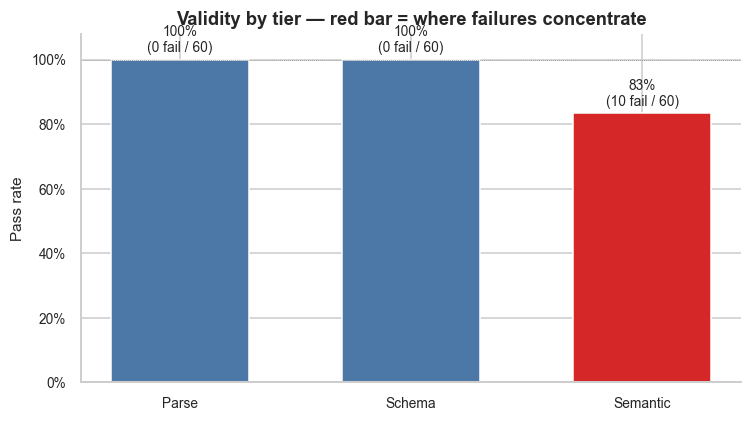

In [6]:
tiers = pd.DataFrame({
    "tier": ["parsed_ok", "schema_pass", "semantic_pass"],
    "label": ["Parse", "Schema", "Semantic"],
    "pass_rate": [df["parsed_ok"].mean(), df["schema_pass"].mean(), df["semantic_pass"].mean()],
    "n_fail": [(~df["parsed_ok"]).sum(), (~df["schema_pass"]).sum(), (~df["semantic_pass"]).sum()],
})
display(tiers)

fig, ax = plt.subplots(figsize=(7, 4))
# Color the weakest tier red; the rest neutral grey.
weakest = tiers["pass_rate"].idxmin()
colors = ["#4c78a8" if i != weakest else "#d62728" for i in range(len(tiers))]
bars = ax.bar(tiers["label"], tiers["pass_rate"], color=colors, edgecolor="white", width=0.6)

ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_ylabel("Pass rate")
ax.set_xlabel("")
ax.set_title("Validity by tier — red bar = where failures concentrate")
ax.axhline(1.0, color="grey", linewidth=0.5, linestyle=":")

for bar, (_, r) in zip(bars, tiers.iterrows()):
    label = f"{r['pass_rate']:.0%}\n({r['n_fail']} fail / {len(df)})"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
            label, ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

,n
family,
Dead-end node (no outgoing flow),7
Zero-entry cycle (no entry point),2
Terminal node with outgoing flow,2


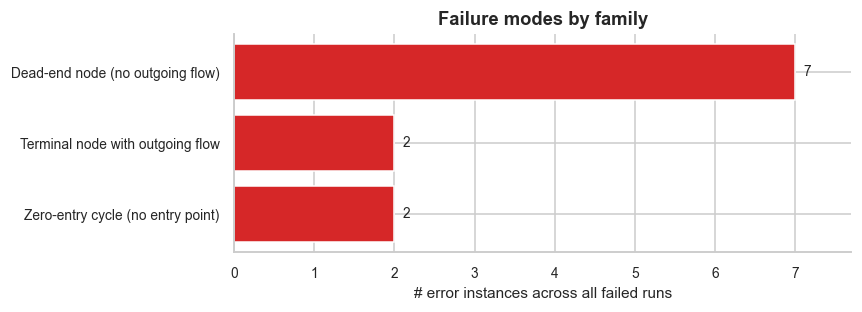

In [7]:
# Semantic error taxonomy: which error families fire most often?
# Keys are matched against the EXACT strings emitted by services/schema_validator.py.
def classify(msg: str) -> str:
    m = msg.lower()
    # Order matters: terminal-with-outgoing must be tested before dead_end (both
    # mention "outgoing flows"). The zero-entry cycle is its OWN family — the
    # validator allows multiple entries and only flags the case where every
    # element has an incoming flow, leaving no entry point.
    if "terminal node" in m and "outgoing" in m:
        return "terminal_with_outgoing"
    if "dead end" in m or "no outgoing flows" in m:
        return "dead_end"
    if "no entry point" in m or "cycle" in m:
        return "no_entry_cycle"
    if "finaloutcome" in m:           # "Process must have at least one finalOutcome."
        return "missing_terminal"
    if "schema error" in m or "additional properties" in m:
        return "schema"
    if "references unknown" in m:     # "Flow 'f' references unknown source/target 'x'."
        return "bad_flow_ref"
    if "duplicate" in m:
        return "duplicate_id"
    return "other"

# Human-readable label for each family key, used on the table and the chart axis.
NICE_FAMILY = {
    "terminal_with_outgoing": "Terminal node with outgoing flow",
    "dead_end": "Dead-end node (no outgoing flow)",
    "no_entry_cycle": "Zero-entry cycle (no entry point)",
    "missing_terminal": "No finalOutcome",
    "schema": "Schema error",
    "bad_flow_ref": "Unknown flow reference",
    "duplicate_id": "Duplicate element ID",
    "other": "Other",
}

err_rows = []
for _, r in df[~df["semantic_pass"] | ~df["schema_pass"]].iterrows():
    for e in r["errors"]:
        err_rows.append({"process_name": r["process_name"], "family": classify(str(e)), "message": str(e)})
errs = pd.DataFrame(err_rows)

if not errs.empty:
    fam = errs.groupby("family").size().sort_values(ascending=True).rename("n")
    display(fam.sort_values(ascending=False).rename(index=NICE_FAMILY).to_frame())

    labels = [NICE_FAMILY.get(k, k) for k in fam.index]
    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(fam) + 1)))
    bars = ax.barh(labels, fam.values, color="#d62728", edgecolor="white")
    ax.set_xlabel("# error instances across all failed runs")
    ax.set_title("Failure modes by family")
    for bar, v in zip(bars, fam.values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                str(int(v)), va="center", fontsize=9)
    ax.margins(x=0.1)
    plt.tight_layout()
    plt.show()
else:
    print("No failures in this run.")

## Over-generation: predicted traces are larger than gold

**Claim:** `element_count_delta = predicted - gold` is positive on average, meaning the LLM elaborates user descriptions into more nodes than the gold trace contains.

**Why it matters:** If true, the post-edit human cost is *trimming* spurious nodes, not adding missing ones. That informs the UI affordances we should prioritize.

,element_count_delta,flow_count_delta,gold_elements,gold_flows,element_ratio
process_name,,,,,
Beam Automated Scribe for Community Care Worker,0.00,2.33,18.0,21.0,1.00
Civic AI Casework Triage,7.33,8.00,15.0,16.0,1.49
Civic AI Congressional Correspondence,5.67,8.67,14.0,15.0,1.40
Civic AI Constituent Sentiment Analysis,11.67,13.33,6.0,5.0,2.94
Civic AI Social Media Drafting,4.00,4.33,8.0,8.0,1.50
Claim Generative Engine Optimization for Webpages,2.33,4.00,12.0,13.0,1.19
CrowdAI Dented Can Identification,1.00,2.67,12.0,13.0,1.08
CrowdAI Fireline Spot Fire Identification,2.00,3.67,12.0,13.0,1.17
Indian Railway Expenditure Agent,5.00,6.67,8.0,8.0,1.62


saved -> evals\figures\overgeneration_per_usecase.png


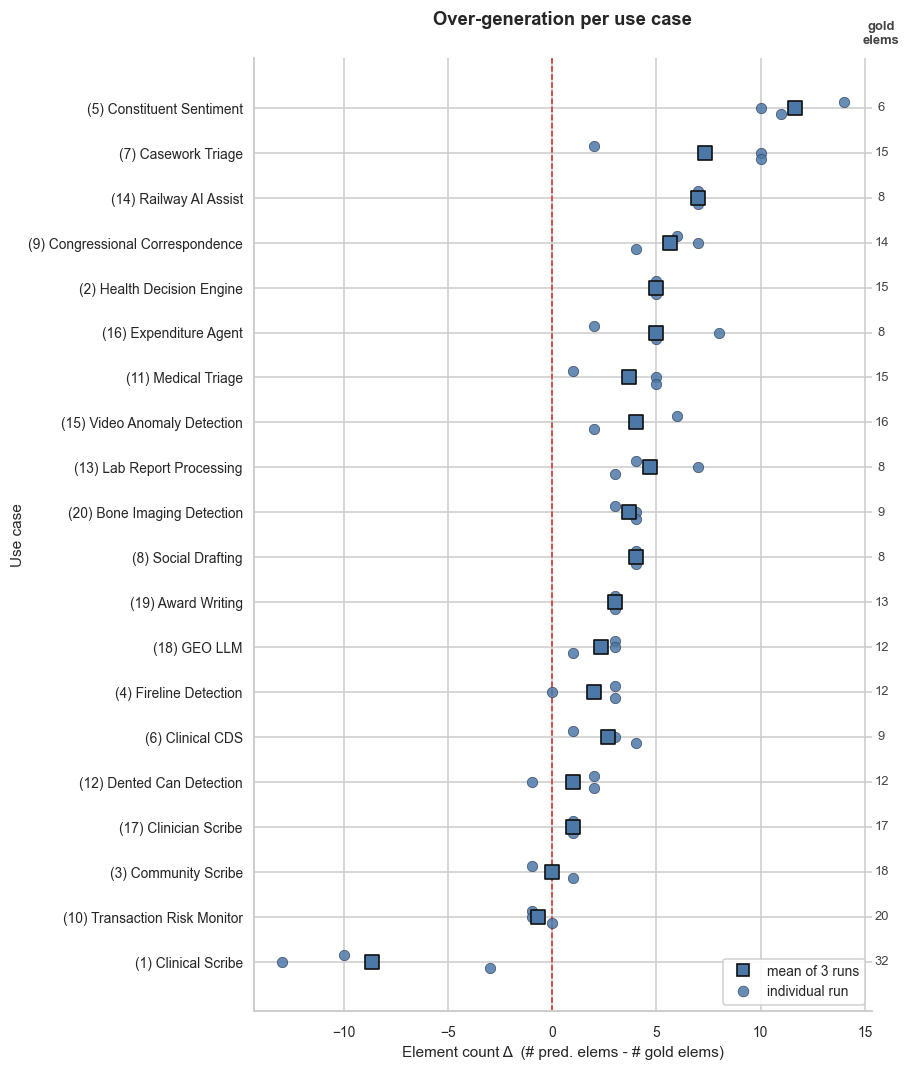

Element delta: mean=+3.22, t=5.85, p=0.0000  (n=60 runs)
Flow delta:    mean=+4.40, t=7.06, p=0.0000  (corroborates: flows also inflate)


In [8]:
# Over-generation: do predictions inflate vs gold? One panel (elements) - flows stated inline.
# Numbers on the y-axis are the swatch numbers from the appendix; the right-hand
# column is the gold element count (printed, not a colour shade, so the size is actually readable).
import matplotlib.transforms as mtransforms
from matplotlib.lines import Line2D

deltas = df.groupby("process_name")[["element_count_delta", "flow_count_delta", "gold_elements", "gold_flows"]].mean()
deltas["element_ratio"] = (deltas["gold_elements"] + deltas["element_count_delta"]) / deltas["gold_elements"]
display(deltas.round(2))

# One-sample t-tests over all rows (n = fixtures x runs = 60), so these have real power;
# the per-fixture markers below rest on only 3 runs each and are shown as raw points.
t_el = stats.ttest_1samp(df["element_count_delta"], 0.0)
t_fl = stats.ttest_1samp(df["flow_count_delta"], 0.0)

# Per-fixture aggregates, sorted so the eye reads top -> bottom as "most over-generated".
g = df.groupby("process_name")
size_map = g["gold_elements"].first()
order_pn = g["element_count_delta"].median().sort_values(ascending=False).index.tolist()

ELEM_COLOR = "#4c78a8"
fig, ax = plt.subplots(figsize=(9, max(5, 0.42 * len(order_pn) + 1.5)))

# Deterministic jitter (no RNG) so the 3 runs of a fixture don't overplot.
jit = {0: -0.14, 1: 0.0, 2: 0.14}
for y, pn in enumerate(order_pn):
    runs = df.loc[df["process_name"] == pn, "element_count_delta"].tolist()
    for k, v in enumerate(runs):
        ax.scatter(v, y + jit.get(k, 0.0), color=ELEM_COLOR, s=46, alpha=0.85,
                   edgecolor="#33415c", linewidth=0.5, zorder=3)
    ax.scatter(np.mean(runs), y, marker="s", s=75, color=ELEM_COLOR,
               edgecolor="#111", linewidth=1.1, zorder=4)

ax.axvline(0, color="#d62728", linestyle="--", linewidth=1, zorder=1)
ax.set_yticks(range(len(order_pn)))
ax.set_yticklabels([fixture_label(pn) for pn in order_pn])
ax.tick_params(axis="y", pad=1)  # pull use-case labels tight against the plot
ax.invert_yaxis()  # most over-generated at top
ax.set_xlabel("Element count Δ  (# pred. elems - # gold elems)")
ax.set_ylabel("Use case", labelpad=2)
ax.set_title("Over-generation per use case", fontsize=12, fontweight="bold", pad=22)

# Marker legend as a boxed legend (rcParams turn frames off globally, so opt back in).
legend_handles = [
    Line2D([0], [0], marker="s", linestyle="", markersize=8, markerfacecolor=ELEM_COLOR,
           markeredgecolor="#111", markeredgewidth=1.1, label="mean of 3 runs"),
    Line2D([0], [0], marker="o", linestyle="", markersize=7, markerfacecolor=ELEM_COLOR,
           markeredgecolor="#33415c", markeredgewidth=0.5, alpha=0.85, label="individual run"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=True,
          facecolor="white", edgecolor="#ccc", framealpha=0.9)

# Gold element count as a printed right-hand column (precise, unlike a colour shade).
trans = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
for y, pn in enumerate(order_pn):
    ax.text(1.015, y, f"{int(size_map[pn])}", transform=trans,
            va="center", ha="center", fontsize=8.5, color="#444")
ax.text(1.015, 1.012, "gold\nelems", transform=ax.transAxes,
        va="bottom", ha="center", fontsize=8.5, color="#444", fontweight="bold")

plt.tight_layout(rect=[0, 0, 0.94, 1])  # leave room on the right for the gold-elems column
savefig("overgeneration_per_usecase")
plt.show()

# Aggregate result + the secondary flow-delta check, stated inline (the headline claim is about elements).
print(f"Element delta: mean={df['element_count_delta'].mean():+.2f}, "
      f"t={t_el.statistic:.2f}, p={t_el.pvalue:.4f}  (n={len(df)} runs)")
print(f"Flow delta:    mean={df['flow_count_delta'].mean():+.2f}, "
      f"t={t_fl.statistic:.2f}, p={t_fl.pvalue:.4f}  (corroborates: flows also inflate)")

### Does over-generation scale with workflow size?

**Claim:** Mean element over-generation (`element_count_delta = predicted - gold`) grows with the gold workflow's size, i.e. the LLM inflates larger processes more in absolute terms.

**Why it matters:** If the gap widens with size, the trimming burden falls hardest on the most complex use cases — exactly where manual editing is most expensive.

n = 20 fixtures
Spearman rho = -0.57, p = 0.0087
OLS: element_count_delta = 10.43 + -0.54 * gold_elements   r^2 = 0.642


saved -> evals\figures\overgeneration_vs_size.png


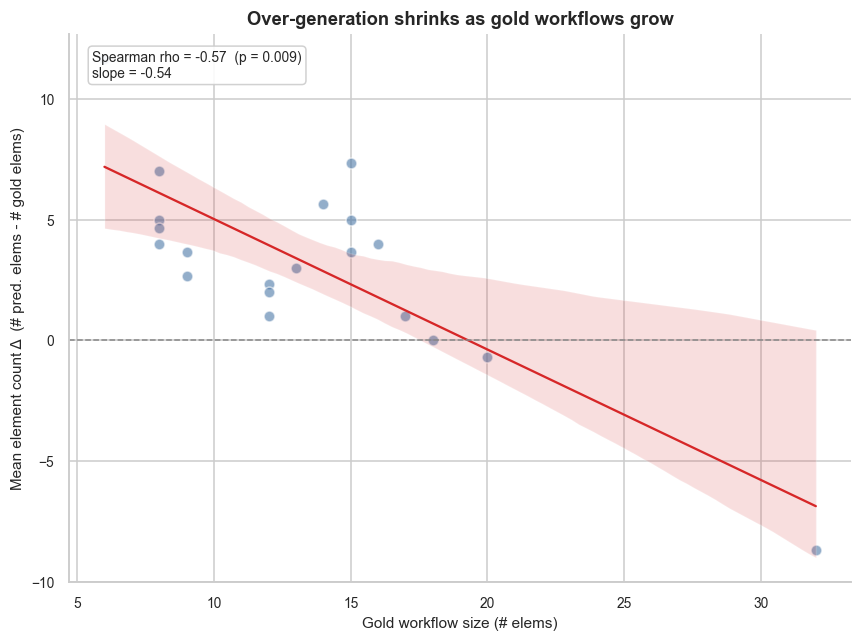

In [9]:
# Per-fixture means: one point per use case (n=20), averaging the 3 runs.
per_fixture = df.groupby("process_name").agg(
    element_count_delta=("element_count_delta", "mean"),
    gold_elements=("gold_elements", "first"),
).reset_index()

sub = per_fixture[["gold_elements", "element_count_delta"]].dropna()
rho, p_sp = stats.spearmanr(sub["gold_elements"], sub["element_count_delta"])
fit = stats.linregress(sub["gold_elements"], sub["element_count_delta"])
print(f"n = {len(sub)} fixtures")
print(f"Spearman rho = {rho:.2f}, p = {p_sp:.4f}")
print(f"OLS: element_count_delta = {fit.intercept:.2f} + {fit.slope:.2f} * gold_elements"
      f"   r^2 = {fit.rvalue**2:.3f}")

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=sub, x="gold_elements", y="element_count_delta", ax=ax,
            scatter_kws={"alpha": 0.6, "s": 50, "edgecolor": "white", "color": "#4c78a8"},
            line_kws={"color": "#d62728", "linewidth": 1.5})
ax.axhline(0, color="#888", linestyle="--", linewidth=1)
ax.set_xlabel("Gold workflow size (# elems)")
ax.set_ylabel("Mean element count Δ  (# pred. elems - # gold elems)")
ax.set_title("Over-generation shrinks as gold workflows grow",
             fontsize=12, fontweight="bold")
ax.text(0.03, 0.97, f"Spearman rho = {rho:.2f}  (p = {p_sp:.3f})\nslope = {fit.slope:.2f}",
        transform=ax.transAxes, va="top", ha="left", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#ccc", alpha=0.9))
plt.tight_layout()
savefig("overgeneration_vs_size")
plt.show()

## Are the traces actually good?

Raw similarity is misleading: every Fabric trace uses the same few element types, so even **unrelated** workflows score high against each other. So we don't trust the number alone — we ask two things:

1. **Does Weaver beat chance?** *Chance* = how similar two unrelated gold traces look. We measure how far above it Weaver sits, in standard deviations. Further above = it captured *this specific* workflow, not just "a valid trace."
2. **Does it match published tools?** We line its scores up against Matei et al. (2026), a state-of-the-art BPMN generator using the same metrics.

Each dimension stands alone — they're on different scales, so we never average them.

**Reading the chart:** bars = SDs above chance. **Blue** = clearly above chance (≥ 2 SD); **grey** = basically chance. Structural/type land grey (any valid trace scores high there); the semantic dimensions land blue — that's where Weaver proves it got *this* workflow right.

,dimension,observed,null_mean,null_sd,z_above_null,gap_closed
0,Structural (shape),0.785,0.729,0.136,0.412,0.207
1,Type-distribution (shape),0.907,0.865,0.087,0.486,0.312
2,Name semantic (meaning),0.565,0.234,0.096,3.466,0.432
3,Name+type semantic (meaning),0.619,0.353,0.110,2.411,0.410


saved -> evals\figures\fidelity_above_chance.png


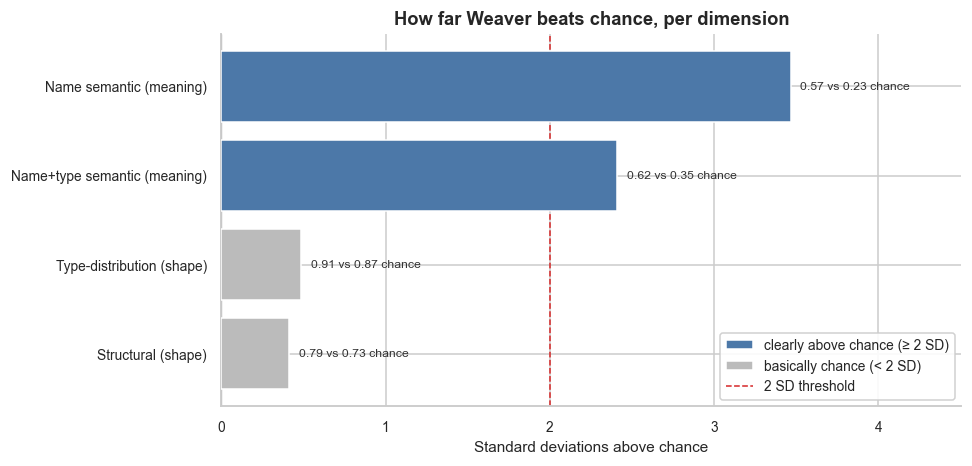

In [10]:
# --- Absolute fidelity #1: distance above chance (gold-vs-gold null) ---
import sys
sys.path.insert(0, str(REPO_ROOT))
from collections import Counter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from services.telemetry import (
    _structural_similarity, _type_distribution_similarity, _semantic_alignment,
)

gold_traces = [w["assistant"] for w in gold]  # all 20, for a richer null

def _dims(pred, g):
    pc = Counter(e["type"] for e in pred["elements"])
    gc = Counter(e["type"] for e in g["elements"])
    sem = _semantic_alignment(pred["elements"], g["elements"])
    return {
        "structural_similarity": _structural_similarity(pred, g),
        "type_distribution_similarity": _type_distribution_similarity(pc, gc),
        "name_semantic_similarity": sem["name_semantic_similarity"],
        "name_type_semantic_similarity": sem["name_type_semantic_similarity"],
    }

# Null = every gold trace scored against every OTHER gold (unrelated but valid).
# Its mean is "chance"; its SD is the noise band a genuine match has to clear.
null_df = pd.DataFrame([
    _dims(gold_traces[i], gold_traces[j])
    for i in range(len(gold_traces)) for j in range(len(gold_traces)) if i != j
])

# (shape)/(meaning) grouping follows the metric definitions in main.tex.
DIMS = ["structural_similarity", "type_distribution_similarity",
        "name_semantic_similarity", "name_type_semantic_similarity"]
NICE = {"structural_similarity": "Structural (shape)",
        "type_distribution_similarity": "Type-distribution (shape)",
        "name_semantic_similarity": "Name semantic (meaning)",
        "name_type_semantic_similarity": "Name+type semantic (meaning)"}

rows = []
for m in DIMS:
    o = df[m].dropna().astype(float); n = null_df[m].dropna().astype(float)
    om, nm, ns = o.mean(), n.mean(), n.std(ddof=1)
    rows.append({"dimension": NICE[m], "observed": om, "null_mean": nm, "null_sd": ns,
                 "z_above_null": (om - nm) / ns if ns else np.nan,
                 "gap_closed": (om - nm) / (1 - nm) if (1 - nm) else np.nan,
                 "ci": 1.96 * o.sem()})
base = pd.DataFrame(rows)
display(base.drop(columns="ci").round(3))

# Bar = SDs above chance (the actual finding), not raw similarity — a long
# similarity bar means nothing when unrelated traces already score high.
order = base.sort_values("z_above_null", ascending=True).reset_index(drop=True)
y = np.arange(len(order))
colors = ["#4c78a8" if z >= 2 else "#bbbbbb" for z in order["z_above_null"]]  # blue = beats chance

fig, ax = plt.subplots(figsize=(9, 0.7 * len(order) + 1.6))
ax.barh(y, order["z_above_null"], color=colors, edgecolor="white", zorder=3)
ax.axvline(0, color="#888", linewidth=0.8)
ax.axvline(2, color="#d62728", linestyle="--", linewidth=1, zorder=2)

for yi, r in order.iterrows():
    ax.text(r["z_above_null"] + 0.06, yi, f"{r['observed']:.2f} vs {r['null_mean']:.2f} chance",
            va="center", fontsize=8, color="#333")

ax.set_yticks(y); ax.set_yticklabels(order["dimension"])
ax.set_xlabel("Standard deviations above chance")
ax.set_title("How far Weaver beats chance, per dimension")

# Colour coding + threshold line in a boxed legend (rcParams turn frames off
# globally, so opt back in — same convention as the over-generation plot).
legend_handles = [
    Patch(facecolor="#4c78a8", edgecolor="white", label="clearly above chance (≥ 2 SD)"),
    Patch(facecolor="#bbbbbb", edgecolor="white", label="basically chance (< 2 SD)"),
    Line2D([0], [0], color="#d62728", linestyle="--", linewidth=1, label="2 SD threshold"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=True,
          facecolor="white", edgecolor="#ccc", framealpha=0.9)
ax.margins(x=0.30)
plt.tight_layout()
savefig("fidelity_above_chance")
plt.show()

### Benchmark: how does Weaver compare to published tools?

Weaver beside the **GPT-4o configuration** of Matei et al. (2026)'s BPMN pipeline, on the four dimensions both define the same way. Two Weaver series: **gpt-5-mini** (the production model) and **gpt-4o** — the *same model* their pipeline uses, which removes model capability as a confound. Weaver makes a *single* LLM call to produce a Fabric trace; their pipeline runs *six* stages to produce BPMN. Matching the model-matched configuration while being much simpler is the point. (Chance levels and SDs above chance are covered in the chance-comparison cell above; Matei et al. publish point estimates only.)

In [ ]:
# --- Absolute fidelity #2: benchmark vs Matei et al. (2026), Tables 2-4 ---
# Their published point estimates (no dispersion published). The figure plots
# only the GPT-4o row — the model-matched comparison — the full table stays
# for reference.
matei = pd.DataFrame({
    "Structural":         {"GPT-4o": 0.805, "Gemini-2.5-flash": 0.810, "Gemini-2.5-pro": 0.817},
    "Type-distribution":  {"GPT-4o": 0.911, "Gemini-2.5-flash": 0.903, "Gemini-2.5-pro": 0.930},
    "Name semantic":      {"GPT-4o": 0.617, "Gemini-2.5-flash": 0.626, "Gemini-2.5-pro": 0.626},
    "Name+type semantic": {"GPT-4o": 0.700, "Gemini-2.5-flash": 0.701, "Gemini-2.5-pro": 0.702},
}).T  # index = dimension, columns = their models

shared = ["structural_similarity", "type_distribution_similarity",
          "name_semantic_similarity", "name_type_semantic_similarity"]
WEAVER_MODELS = list(RUNS)

means = {m: [df_all.loc[df_all["model"] == m, c].dropna().mean() for c in shared]
         for m in WEAVER_MODELS}

bench = matei.copy()
for m in reversed(WEAVER_MODELS):
    bench.insert(0, f"Weaver ({m})", means[m])
display(bench.round(3))

# Figure: 3 bars per dimension — Weaver in blues, Matei in red, so the two
# tools are distinguishable at a glance. Labels use the lowercase API model
# ids throughout (matei["GPT-4o"] below is the internal lookup key, not shown).
series = [(f"Weaver (gpt-5-mini)", means["gpt-5-mini"], "#4c78a8"),
          (f"Weaver (gpt-4o)", means["gpt-4o"], "#9ecae1"),
          ("Matei et al. (gpt-4o)", matei["GPT-4o"].tolist(), "#e45756")]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(matei.index))
w = 0.26
for k, (label, vals, color) in enumerate(series):
    bars = ax.bar(x + (k - 1) * w, vals, w, label=label, color=color, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=10, color="#333")

ax.set_xticks(x); ax.set_xticklabels(matei.index, rotation=10)
ax.set_ylim(0, 1.0); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_ylabel("Mean similarity")
ax.set_title("Fidelity by dimension: Weaver vs. Matei et al. (2026)")
# Colour legend boxed in the top-right corner, clear of the (shorter) right-hand bars.
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#ccc", framealpha=0.9)
plt.tight_layout()
savefig("fidelity_vs_matei")
plt.show()

### Per-model validity

Fidelity conditions on validity: the benchmark above scores only runs that produced a parseable trace, and the dissertation reports fidelity only over structurally valid ones. The two models have different conditioning sets, so their pass rates must be reported alongside the similarity scores.

In [12]:
# Per-model validity. Similarity means above are computed only over runs that
# produced a parseable trace, so a model with a lower parse rate is scored on
# fewer runs (selection effect) — n_scored makes that explicit.
validity = df_all.groupby("model").agg(
    n_runs=("run_idx", "size"),
    parse_rate=("parsed_ok", "mean"),
    schema_rate=("schema_pass", "mean"),
    semantic_rate=("semantic_pass", "mean"),
    n_scored=("structural_similarity", "count"),
).round(4)
display(validity)

,n_runs,parse_rate,schema_rate,semantic_rate,n_scored
model,,,,,
gpt-4o,60,1.0,1.0,0.6500,60
gpt-5-mini,60,1.0,1.0,0.8333,60


## Completion tokens scale ~linearly with output size

**Claim:** `completion_tokens ~ a + b * (num_elements + num_flows)`. Prompt tokens are near-constant per fixture (system prompt + 3 few-shots + ~same user msg), so cost variation falls on the output side and tracks workflow size.

**Why it matters:** Backs the cost-section claim that input is effectively fixed while output scales with the generated graph.

In [13]:
df["output_size"] = df["num_elements"] + df["num_flows"]
fit = stats.linregress(df["output_size"], df["completion_tokens"])
print(f"completion_tokens = {fit.intercept:.1f} + {fit.slope:.1f} * (elements+flows)   r^2 = {fit.rvalue**2:.3f}")
print(f"prompt_tokens: mean={df['prompt_tokens'].mean():.0f}, stdev={df['prompt_tokens'].std():.1f}")

completion_tokens = 645.0 + 73.1 * (elements+flows)   r^2 = 0.394
prompt_tokens: mean=3338, stdev=29.1


### Cost per trace (USD, converted at analysis time)

The harness logs tokens, never USD — prices are applied here so they stay updatable. Averages are over **all** runs, valid or not, since invalid traces are billed too. Two caveats:

1. **Upper bound:** full input price is assumed. OpenAI prompt caching would discount the repeated system-prompt + few-shot prefix (~3.3k tokens), and cached-token counts are not logged.
2. **Reasoning tokens:** gpt-5-mini's `completion_tokens` include billed invisible reasoning tokens — the USD figure is correct (reasoning bills at the output rate), but raw completion counts are not a like-for-like verbosity comparison with gpt-4o.

In [14]:
# USD per 1M tokens (input, output) — official OpenAI per-model docs, retrieved 2026-06-09:
#   gpt-5-mini: https://developers.openai.com/api/docs/models/gpt-5-mini
#   gpt-4o:     https://developers.openai.com/api/docs/models/gpt-4o
PRICING = {"gpt-5-mini": (0.25, 2.00), "gpt-4o": (2.50, 10.00)}

c = df_all.copy()  # ALL runs, valid or not — tokens are billed regardless of validity
c["cost_usd"] = c.apply(
    lambda r: r["prompt_tokens"] / 1e6 * PRICING[r["model"]][0]
    + r["completion_tokens"] / 1e6 * PRICING[r["model"]][1],
    axis=1,
)
n_api_err = c["api_error"].notna().sum()  # usage=None rows carry 0 tokens and deflate the mean
if n_api_err:
    print(f"NOTE: {n_api_err} run(s) had API errors (0 tokens recorded).")

cost_tbl = c.groupby("model").agg(
    n_runs=("cost_usd", "size"),
    prompt_tokens_mean=("prompt_tokens", "mean"),
    completion_tokens_mean=("completion_tokens", "mean"),
    latency_s_mean=("latency_ms", lambda s: s.mean() / 1000),
    cost_usd_mean=("cost_usd", "mean"),
    cost_usd_median=("cost_usd", "median"),
).round(4)
display(cost_tbl)

for m, total in c.groupby("model")["cost_usd"].sum().items():
    print(f"{m}: full 60-run eval cost ${total:.3f}")

,n_runs,prompt_tokens_mean,completion_tokens_mean,latency_s_mean,cost_usd_mean,cost_usd_median
model,,,,,,
gpt-4o,60,3332.9,642.0833,6.5447,0.0148,0.0149
gpt-5-mini,60,3337.9,3221.3833,45.0949,0.0073,0.0071


gpt-4o: full 60-run eval cost $0.885
gpt-5-mini: full 60-run eval cost $0.437


## Quick takeaways table

Per-fixture cheat sheet for the dissertation chapter. Mean values across N runs.

In [15]:
agg_spec = dict(
    n_runs=("run_idx", "count"),
    gold_elements=("gold_elements", "first"),
    pred_elements_mean=("num_elements", "mean"),
    element_delta_mean=("element_count_delta", "mean"),
    semantic_pass_rate=("semantic_pass", "mean"),
    structural_sim_mean=("structural_similarity", "mean"),
    type_dist_sim_mean=("type_distribution_similarity", "mean"),
    total_tokens_mean=("total_tokens", "mean"),
    latency_s_mean=("latency_ms", lambda s: s.mean() / 1000),
)
# Only include meaning metrics if the semantic deps were available at run time.
if df["name_semantic_similarity"].notna().any():
    agg_spec["name_sem_mean"] = ("name_semantic_similarity", "mean")

out = df.groupby("process_name").agg(**agg_spec).round(2)
# Order by appendix swatch number and re-key with the '(swatch no.) Short Label' convention.
out["rank"] = [USE_CASE_RANK.get(p) for p in out.index]
out = out.sort_values("rank").drop(columns="rank")
out.index = [fixture_label(p) for p in out.index]
out.index.name = "use case (swatch no. · label)"
out

,n_runs,gold_elements,pred_elements_mean,element_delta_mean,semantic_pass_rate,structural_sim_mean,type_dist_sim_mean,total_tokens_mean,latency_s_mean,name_sem_mean
use case (swatch no. · label),,,,,,,,,,
(1) Clinical Scribe,3,32,23.33,-8.67,0.33,0.79,0.90,8204.00,134.41,0.58
(2) Health Decision Engine,3,15,20.00,5.00,0.67,0.80,0.96,5698.33,25.07,0.54
(3) Community Scribe,3,18,18.00,0.00,1.00,0.91,0.87,6873.67,45.23,0.75
(4) Fireline Detection,3,12,14.00,2.00,1.00,0.83,0.93,7327.33,66.06,0.64
(5) Constituent Sentiment,3,6,17.67,11.67,0.33,0.51,0.85,6376.00,32.59,0.25
(6) Clinical CDS,3,9,11.67,2.67,1.00,0.82,0.87,5266.00,22.25,0.53
(7) Casework Triage,3,15,22.33,7.33,0.33,0.76,0.93,7801.00,91.16,0.51
(8) Social Drafting,3,8,12.00,4.00,0.67,0.74,0.85,5806.67,28.44,0.55
(9) Congressional Correspondence,3,14,19.67,5.67,1.00,0.75,0.89,8111.00,72.73,0.50
